<a href="https://colab.research.google.com/github/charlottemarieolexy-tech/A01-data-wrangling-Olexy/blob/main/A01_official.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.
# Exploring dataset and its properties
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/charl/Downloads/airbnb_hw.csv") #reading in the airbnb_hw csv and setting it to df

print(df.shape, '\n') #30478 rows 13 columns
print(df.dtypes, '\n') #looking at data types of each column
print(df.head(), '\n')


(30478, 13) 

Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 

    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Ty

Printing the df[var] and its type:
 0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: str <class 'pandas.Series'> 

Before turning to a numeric variable:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

Showing Price of greater than $1000 before converting the attribute to a Numeric:

Row with label 101: 
Host Id                                        8730
Host Since                                2/27/2009
Name                          Comfort & Convenience
Neighbourhood                             Manhattan
Property Type                           Condominium
Review Scores Rating (bin)                    100.0
Room Type                           Entire home/apt
Zipcode                                     10003.0
Beds                                            6.0
Number of Records                                 1


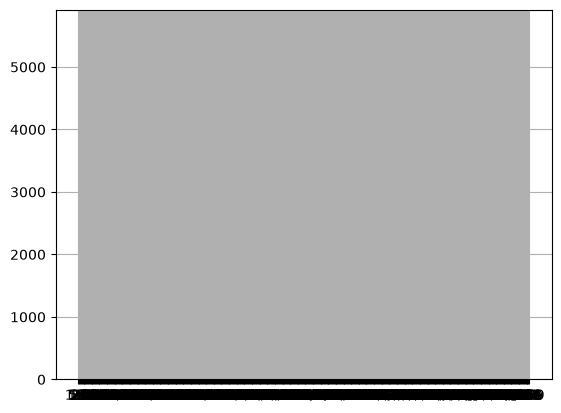

In [ ]:
#Exploring Price Attribute
var = "Price"
print("Printing the df[var] and its type:\n", df[var], type(df[var]), '\n')

print("Before turning to a numeric variable:\n", df[var].describe(), '\n')
df[var].hist(bins = 50)

#Also Price Variable for amounts above $1000 contain a "," comma
print("Showing Price of greater than $1000 before converting the attribute to a Numeric:")
row_101 = df.loc[101]
print("\nRow with label 101: ")
print(row_101)

Printing the df[var] with unique():
 [  145    37    28   199   549   149   250    90   270   290   170    59
    49    68   285    75   100   150   700   125   175    40    89    95
    99   499   120    79   110   180   143   230   350   135    85    60
    70    55    44   200   165   115    74    84   129    50   185    80
   190   140    45    65   225   600   109  1990    73   240    72   105
   155   160    42   132   117   295   280   159   107    69   239   220
   399   130   375   585   275   139   260    35   133   300   289   179
    98   195    29    27    39   249   192   142   169  1000   131   138
   113   122   329   101   475   238   272   308   126   235   315   248
   128    56   207   450   215   210   385   445   136   247   118    77
    76    92   198   205   299   222   245   104   153   349   114   320
   292   226   420   500   325   307    78   265   108   123   189    32
    58    86   219   800   335    63   229   425    67    87  1200   158
   650   234  

<Axes: >

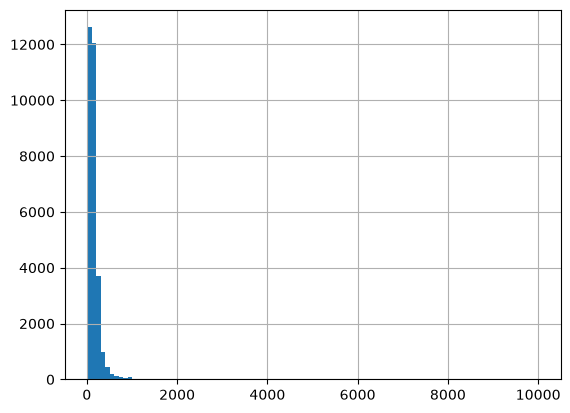

In [ ]:
#Changing to Numeric
df[var] = pd.to_numeric(df[var].str.replace(',',''), errors = 'coerce')


print("Printing the df[var] with unique():\n", df[var].unique(), '\n')
print("Printing the df[var] with value_counts():\n", df[var].value_counts(), '\n')

print("After coercion: \n", df[var].describe(), '\n')
df[var].hist(bins = 100)

In [ ]:
#Missing Data
missing_price_data = df[df[var].isnull()]
print(missing_price_data, type(missing_price_data)) #There were 181 NaN values in the Price attribute

#Reprint DataFrame
df[var]



Empty DataFrame
Columns: [Host Id, Host Since, Name, Neighbourhood , Property Type, Review Scores Rating (bin), Room Type, Zipcode, Beds, Number of Records, Number Of Reviews, Price, Review Scores Rating]
Index: [] <class 'pandas.DataFrame'>


0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: int64

When handling this data set, I first read in the csv and gathered some initial insights on the shape of the data using methods like df.shape() and df.head(). Our task was to clean the Price variable so I then went to examine this attribute by itself by filtering the DataFrame to just the values of the Price attribute and the type of objects that the Price values were (str <class "panda.Series">). Since Price should be read as a numeric variable, I called a histogram of the attribute to see if python was reading the column values as numerics. However, when I ran the histogram method, the graph showed that python was not reading the values of numerics. My next step was to convert the Price values to numerics using the pd.to_numeric method. Once I converted the values, I ran a new histogram which showed a right-skewed distribution of the Price values.
My next step to clean the Price Variable was to take care of potential missing values. I used the .isnull() method to pull the rows that had NaN Price values. I found that Python was reading 181 NaN values. I also realized that none of the values in the new numeric DataFrame were greater than 999. So I went back to my earlier code, before I had coerced the Price variable into a numeric, and called the row of one of the values that read NaN when I used .isnull(). This showed me that the NaN value after coercion was actually a Price value of greater than 999 with a comma (e.g. 1,200). As a solution, I added a line of code that stripped the Price variables over 999 of the comma before I converted them to a numeric variable. This changed the values that were previously NaN to now readble as numerica values over 999.
Then I ran my DataFrame to confirm the variable was clean.

In [ ]:
#Question 1 Part 2

police = pd.read_csv("C:/Users/charl/Downloads/mn_police_use_of_force.csv")

print(police.shape, '\n')
print(police.head(),'\n')
print(police["subject_injury"], '\n')

print(police["subject_injury"].unique(), '\n')
subject_type_uniq_val = police["subject_injury"].unique()

print(subject_type_uniq_val[1], len(subject_type_uniq_val[1]), '\n')
print(subject_type_uniq_val[2], len(subject_type_uniq_val[2]), '\n')

see_null = police['subject_injury'].notnull()
only_not_null = see_null[see_null == True]
print(only_not_null) #3077 values that are not NaN

see_is_null = police['subject_injury'].isnull()
only_is_null = see_is_null[see_is_null == True]
print(only_is_null) #9848 values that are NaN --> 2/3 of the values are missing which is not good

(12925, 13) 

     response_datetime               problem is_911_call primary_offense  \
0  2016/01/01 00:47:36  Assault in Progress          Yes          DASLT1   
1  2016/01/01 02:19:34                Fight           No          DISCON   
2  2016/01/01 02:19:34                Fight           No          DISCON   
3  2016/01/01 02:28:48                Fight           No          PRIORI   
4  2016/01/01 02:28:48                Fight           No          PRIORI   

  subject_injury         force_type   force_type_action   race     sex   age  \
0            NaN       Bodily Force  Body Weight to Pin  Black    Male  20.0   
1            NaN  Chemical Irritant       Personal Mace  Black  Female  27.0   
2            NaN  Chemical Irritant       Personal Mace  White  Female  23.0   
3            NaN  Chemical Irritant  Crowd Control Mace  Black    Male  20.0   
4            NaN  Chemical Irritant  Crowd Control Mace  Black    Male  20.0   

         type_resistance  precinct   neighborhoo

In [ ]:
#Cross Tabulation
pd.crosstab(police["subject_injury"], police["force_type"])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal Projectile,Police K9 Bite,Taser
subject_injury,,,,,,,,,
No,0,1093,131,2,33,34,1,2,150
Yes,2,1286,41,0,44,40,2,44,172


For part 2 of Q1, I read the police csv file in. I then got an initial feel for the shape of the whole DataFrame and then focused in on the Subject_injury variable. I first looked at the variable's unique values to see if there were any hidden missing values and identified that there was only [NaN, "Yes", "No"]. Then I looked to see if these unique values needed to be stripped of any white_space, which they did not. Then I counted how many NaN values there were in comparison to the "Yes" and "No" values. This is where I realized that about 2/3 of the subject_injury variable was missing. If a data scientist were to run an analysis that included the subject_injury variable this would pose problems. We see these problems when I cross-tabulated the subject_injury variable with the force_type variable. Since the subject_injury variable is missing so many values, the cross-tabulation only compares the not NaN values of "Yes" and "No" to its corresponding force_type values. The cross-tabulation thus does not show the data that we do have in the force_type variable, excluding a chunk of data that could be useful and making possible analyses less precise.

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

<Axes: >

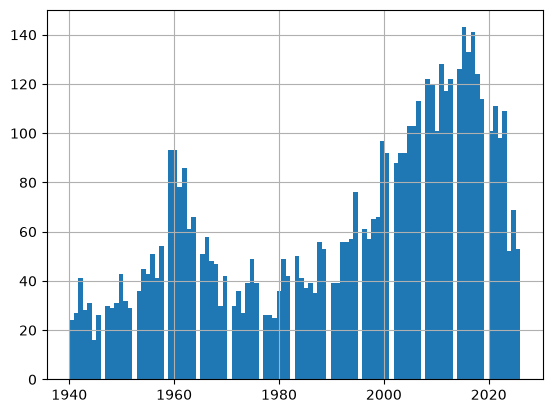

In [ ]:
#Question 2

shark_df = pd.read_excel("C:/Users/charl/Downloads/GSAF5.xls")

print(shark_df.head(), '\n')

print(shark_df.columns, '\n')

shark_df.drop(["pdf","href formula","href",'Case Number','Case Number.1','original order','Unnamed: 21', "Unnamed: 22"], axis =1)

print(shark_df["Year"].unique())

shark_df = shark_df[~shark_df["Year"].isin([0, 5, 77,1000])] #dropped year values that don't make sense (0, 5, 77, 1000)

print(shark_df["Year"].unique(), '\n')

shark_df = shark_df.query("Year >= 1940")

print(shark_df["Year"],'\n')

shark_df['Year'].hist(bins = 100)

For Q2, I loaded in the xls shark victim data set using the imported xlrd library. I then got an initial assessment of the dataset and dropped columns that did not have any data. My following task was to clean the Year variable, so I called the variable's unique values. I dropped the ones that were values that did not make sense in the context of the variable. I then filtered the Year variable to attacks from 1940 on and plotted it on a histogram. From the histogram, I analyzed that the number of shark attacks over the years since 1940 is increasing. There appears to have been a surge in attacks around 1960. The number of attacks then began to rapidly increase beginning in 1990 until it starting declining in 2020 when Covid 19 was at its peak.

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

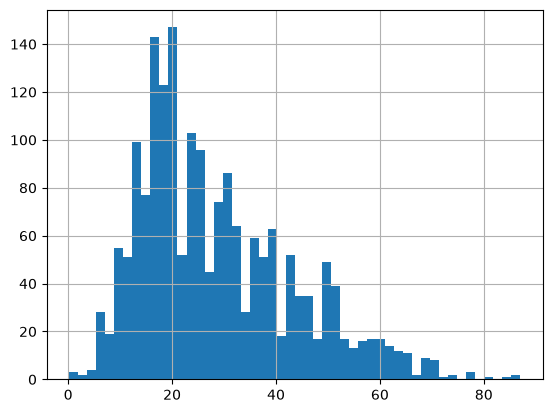

In [ ]:
#Cleaning Age Variable

import re

print(shark_df["Age"].unique(), '\n')

shark_df = shark_df[~shark_df["Age"].isin(['MAKE LINE GREEN', "F", 'M', "\"young\"", "", "\xa0", "a minor", "Elderly", "\"middle-age\"", "0", "(adult)", "Teens"])]

shark_df["Age"] = shark_df["Age"].replace(["?", "X", " ", "teen","Middle age", "20/30", "mid-20s", "Teen"], [np.nan, np.nan, np.nan, "16", "50", "25", "25", "16"])

shark_df["Age"] = shark_df['Age'].replace(["mid-30s"], ["35"])

shark_df["Age"] = shark_df["Age"].replace(["18 months", "9 months", "6½", "2 to 3 months"], ["1.5","0.75", "6.5", "0.21"])

to_remove = ["'s", "+", "!", "?", ">", "Ca. 33", "s"]

for item in to_remove:
    shark_df["Age"] = shark_df["Age"].str.replace(item, "")

print(shark_df["Age"].unique(), '\n')

unique_values = shark_df["Age"].unique()
print(type(unique_values))

list_of_unique_val_list = []
for value in unique_values:
    print(value)
    string_value = str(value)
    value = re.findall(r'\d+(?:\.\d+)?', string_value)
    print(value)
    list_of_unique_val_list += [value]


print(list_of_unique_val_list)

list_of_avg_unique_val_list = []
for lst in list_of_unique_val_list:
    total = 0
    num_i = 0
    for i in lst:
        total += float(i)
        num_i += 1

    if num_i == 0:
        average = None
    else:
        average = total/num_i

    list_of_avg_unique_val_list.append(average)

print(list_of_avg_unique_val_list)

shark_df["Age"] = shark_df["Age"].map(dict(zip(unique_values, list_of_avg_unique_val_list)))

print(shark_df["Age"].unique())

shark_df["Age"].hist(bins=50)


The Age variable was hard to clean becaause it was a very dirty variable. I started by looking at the unique values to assess what I was workign with. Then, I dropped text that wasn't a numeric Age or did not make sense in the context of an analysis. I then stripped certain values of extra text that made them unreadable as numeric by Python.

From here, I had to assess how to deal with the values that were strings of more than one age. I did not want to drop all of this because that would be a loss of a lot of data. So I created a for loop to extract the numerics in the strings and put them into a list of lists. I did this by googling how to extract numerics from a string and discovered the utility of regex functions. I used the code r'\d+(?:\.\d+)?' which extracts both integers and decimals. Then with my new list of lists, I used a nested for loop to calculate the average of the numbers within each list and returned a new list of float (numeric) values that reflected all of the unique Age values.

Now that I had cleaned the variable, I needed to map it back to the original Data Frame Age Series. So after some digging on Google, I found how to zip together the each old list and its newly computed average value. With these "zipped" together values into a tuple, I made them into a dictionary so then I could map it back to the DataFrame Age Series using the map function.

Then I plotted a histogram of the ages and found that people ranging from age 16 to mid-30s had the highest victim count.

<StringArray>
['F', 'M', 'M ', 'M F', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2']
Length: 11, dtype: str
<StringArray>
['F', 'M', nan]
Length: 3, dtype: str


<Axes: >

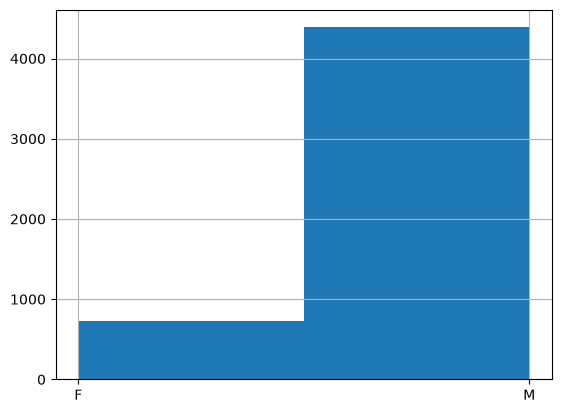

In [ ]:
#Victims Male

print(shark_df["Sex"].unique())

shark_df = shark_df[~shark_df["Sex"].isin(["lli", "?", 'M F', "N", '.'])]

shark_df["Sex"] = shark_df["Sex"].str.upper()

shark_df["Sex"] = shark_df["Sex"].str.strip(" X 2")

print(shark_df["Sex"].unique())

shark_df["Sex"].hist(bins = 2)

In this section, I cleaned the Sex variable. I first looked at the unique values and then dropped uniqe values that had no relation to any gender. Then, I capitalized the rest of the values to be a uniform style and stripped them of any whitespace and irrelevant parts. I finished by plotting a histogram to see the ratio of male to female attacks. In relation to female victims, men were attacked almost 6x that of women.

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str
<StringArray>
['Unprovoked', 'Provoked', 'Unknown', nan]
Length: 4, dtype: str


<Axes: >

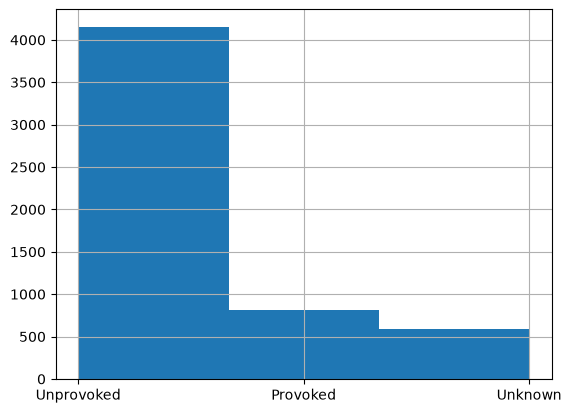

In [ ]:
#Clean Type Variable

print(shark_df["Type"].unique())

shark_df["Type"] = shark_df["Type"].str.title()

shark_df["Type"] = shark_df["Type"].replace(["?", "Invalid", "Unverified", "Questionable", "Unconfirmed", "Under Investigation", "Boat", "Watercraft", "Sea Disaster" ],[np.nan, "Unknown","Unknown","Unknown", "Unknown", "Unknown", "Provoked", "Provoked", "Unknown"])

shark_df["Type"] = shark_df["Type"].str.strip(" ")

print(shark_df["Type"].unique())

shark_df["Type"].hist(bins=3)


Here, I first viewed the unique values of the Type variable. I then replaced any unique values that were another word for "Unknown" or "Provoked", or it was unclear. After, I stripped the unique values of white space and then plotted them on a histogram for analysis. From the histogram, the number of unprovoked attacks was over 2x the sum of both provoked and unknown attacks.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 9f0ae94
- **AI tool and model used:** Microsoft Copilot version 152.0.4191.64 (Official build) (64-bit)

### *Prompts used

1. [give me some places that i can clean my code or make it more efficient - intermediate python level friendly:]
2. [for the variables, i don't want to drop the NaN values]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. 1. Repeated printing / exploring steps
You repeatedly print shapes, dtypes, heads, and unique values. That's fine while exploring, but in a final notebook:

Group exploration together.

Remove prints that don't add new information.

Cleaner pattern:

print(df.shape)
print(df.dtypes)
df.head()

2. Price cleaning can be simplified
You used:

df[var] = pd.to_numeric(df[var].str.replace(',',''), errors='coerce')

This is already the correct solution.
But you don't need to print .unique() and .value_counts() unless you're analyzing them.

Also, you created:

df['price_nan'] = df[var].isnull()

You never use price_nan. Remove it.

3. Police dataset: counting missing values
You wrote:

see_null = police['subject_injury'].notnull()
only_not_null = see_null[see_null == True]
print(only_not_null)

This prints thousands of booleans.

Instead, use:

police['subject_injury'].isnull().sum()
police['subject_injury'].notnull().sum()

Much cleaner and faster.

4. Shark dataset: dropping columns
You wrote:

shark_df.drop([...], axis=1)

But you forgot to assign it back.
So the columns were never dropped.

Should be:

shark_df = shark_df.drop([...], axis=1)

5. Year cleaning
You manually removed weird values:

shark_df = shark_df[~shark_df["Year"].isin([0, 5, 77, 1000])]

Better approach: convert to numeric first, then drop invalid years.

shark_df['Year'] = pd.to_numeric(shark_df['Year'], errors='coerce')
shark_df = shark_df[(shark_df['Year'] >= 1800) & (shark_df['Year'] <= 2026)]

This avoids hard-coding specific bad values.

6. Age cleaning: your biggest opportunity
Your regex + list-of-lists + averaging logic works, but it's very long and can be simplified while still using loops.

Problems:
You drop many values manually.

You replace many values manually.

You build a list of lists, then average them, then map back.

Cleaner intermediate-friendly approach:

cleaned_ages = []

for age in shark_df["Age"]:
    if pd.isna(age):
        cleaned_ages.append(None)
        continue

    age_str = str(age)

    # extract numbers
    nums = re.findall(r'\d+(?:\.\d+)?', age_str)

    if len(nums) == 0:
        cleaned_ages.append(None)
    elif len(nums) == 1:
        cleaned_ages.append(float(nums[0]))
    else:
        # average multiple numbers
        total = 0
        for n in nums:
            total += float(n)
        cleaned_ages.append(total / len(nums))

shark_df["Age"] = cleaned_ages

This removes the need for:

dropping dozens of text values manually

building a list of unique values

zipping dictionaries

mapping back to the dataframe

It's cleaner, shorter, and easier to debug.

7. Sex cleaning
You wrote:

shark_df["Sex"] = shark_df["Sex"].str.strip(" X 2")

This doesn't do what you think — .strip() removes characters from both ends, not inside the string.

Better:

shark_df["Sex"] = shark_df["Sex"].str.upper().str.replace(" ", "")

Then drop invalid values:

valid_sex = ["M", "F"]
shark_df = shark_df[shark_df["Sex"].isin(valid_sex)]

8. Type cleaning
You manually replaced many values:

shark_df["Type"] = shark_df["Type"].replace([...])

Better pattern:

type_map = {
    "Invalid": "Unknown",
    "Unverified": "Unknown",
    "Questionable": "Unknown",
    "Unconfirmed": "Unknown",
    "Under Investigation": "Unknown",
    "Boat": "Provoked",
    "Watercraft": "Provoked",
    "Sea Disaster": "Unknown"
}

shark_df["Type"] = shark_df["Type"].str.title()
shark_df["Type"] = shark_df["Type"].replace(type_map)

Cleaner, readable, and easy to update.

9. Avoid printing huge arrays
You printed entire .unique() arrays multiple times.
This slows the notebook and adds clutter.

Better:

print(len(shark_df["Age"].unique()))

Or:

print(shark_df["Age"].unique()[:20])

10. Use functions to organize repeated cleaning
Your notebook is long because everything is inline.

You can make it cleaner by defining small helper functions:

def clean_price(series):
    return pd.to_numeric(series.str.replace(",", ""), errors="coerce")

def extract_age(age):
    # your regex logic here
This makes your notebook shorter and easier to read.

Prompt 2 Response:

Got you — if you don’t want to drop NaN values, then the goal becomes:

Clean the non‑missing values

Leave NaN exactly as they are

Avoid filtering rows out of the dataset

Make your cleaning code more efficient and readable

Here are the places in your notebook where you can improve efficiency without dropping NaNs.

1. Price variable — simplify cleaning (keep NaNs)
Your current workflow is correct, but you can remove extra steps.

Your code:
You print tons of diagnostics

You create price_nan but never use it

You manually inspect rows > 999

Cleaner version (keeps NaNs):

df["Price"] = (
    df["Price"]
    .str.replace(",", "")     # remove commas
    .pipe(pd.to_numeric, errors="coerce")   # convert to numeric
)

This does everything you need in one readable block.

2. Police dataset — counting missing values more efficiently
You currently do:

see_null = police['subject_injury'].notnull()
only_not_null = see_null[see_null == True]
print(only_not_null)

This prints thousands of booleans.

Cleaner version:

missing = police["subject_injury"].isna().sum()
non_missing = police["subject_injury"].notna().sum()

This keeps NaNs and gives you the counts directly.

3. Shark dataset — column dropping
You wrote:

shark_df.drop([...], axis=1)

But you didn’t assign it back, so nothing was dropped.

Cleaner:

shark_df = shark_df.drop([...], axis=1)

This keeps NaNs in the remaining columns.

4. Year cleaning — avoid hard‑coding weird values
You manually removed [0, 5, 77, 1000].

Better approach: convert to numeric and let invalid values become NaN (which you keep).

shark_df["Year"] = pd.to_numeric(shark_df["Year"], errors="coerce")

Then filter only the years you want without dropping NaNs:

shark_df_recent = shark_df[shark_df["Year"] >= 1940]

Rows with Year = NaN stay in shark_df but are excluded from the filtered view — no dropping.

5. Age cleaning — your biggest opportunity
Your current approach:

Drops many values manually

Builds list‑of‑lists

Averages values

Zips dictionaries

Maps back

This is way more work than needed, and you drop many values unnecessarily.

Cleaner intermediate‑friendly version (keeps NaNs):

cleaned_ages = []

for age in shark_df["Age"]:
    if pd.isna(age):
        cleaned_ages.append(None)
        continue

    nums = re.findall(r'\d+(?:\.\d+)?', str(age))

    if len(nums) == 0:
        cleaned_ages.append(None)
    elif len(nums) == 1:
        cleaned_ages.append(float(nums[0]))
    else:
        total = 0
        for n in nums:
            total += float(n)
        cleaned_ages.append(total / len(nums))

shark_df["Age"] = cleaned_ages

This keeps NaNs, handles messy strings, and avoids dropping any rows.

6. Sex variable — avoid dropping NaNs
You currently drop values like "?", "N", ".", "M F".

Instead, convert invalid values to NaN (which you keep):

shark_df["Sex"] = shark_df["Sex"].str.upper().str.replace(" ", "")

valid = ["M", "F"]
shark_df.loc[~shark_df["Sex"].isin(valid), "Sex"] = None

This keeps the row but marks the sex as missing.

7. Type variable — simplify replacement
You manually replace many values.

Better:

type_map = {
    "Invalid": "Unknown",
    "Unverified": "Unknown",
    "Questionable": "Unknown",
    "Unconfirmed": "Unknown",
    "Under Investigation": "Unknown",
    "Boat": "Provoked",
    "Watercraft": "Provoked",
    "Sea Disaster": "Unknown"
}

shark_df["Type"] = shark_df["Type"].str.title().replace(type_map)
No rows dropped, NaNs preserved.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | I chose to keep the AI basic code structure to clean the age, type, and sex variables in Q2. It made it more efficient and easier to debug. |
| 2 | Accept / **modify** / reject | I modified certain aspects of each recommendation because when I ran the recommended code, it dropped the NaN values and did not always delete some of the irrelevant unique values.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/charl/Downloads/airbnb_hw.csv") #reading in the airbnb_hw csv and setting it to df

print(df.shape, '\n') #30478 rows 13 columns
print(df.dtypes, '\n') #looking at data types of each column
df.head()


(30478, 13) 

Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 



,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Printing the df[var] and its type:
 0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: str <class 'pandas.Series'> 

Before turning to a numeric variable:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

Showing Price of greater than $1000 before converting the attribute to a Numeric:

Row with label 101: 
Host Id                                        8730
Host Since                                2/27/2009
Name                          Comfort & Convenience
Neighbourhood                             Manhattan
Property Type                           Condominium
Review Scores Rating (bin)                    100.0
Room Type                           Entire home/apt
Zipcode                                     10003.0
Beds                                            6.0
Number of Records                                 1


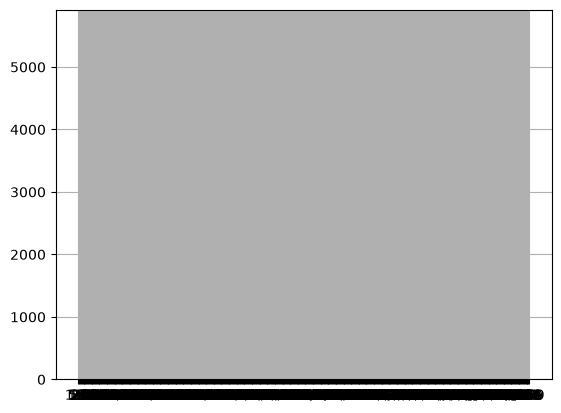

In [ ]:
#Exploring Price Attribute
var = "Price"
print("Printing the df[var] and its type:\n", df[var], type(df[var]), '\n')

print("Before turning to a numeric variable:\n", df[var].describe(), '\n')
df[var].hist(bins = 50)

#Also Price Variable for amounts above $1000 contain a "," comma
print("Showing Price of greater than $1000 before converting the attribute to a Numeric:")
row_101 = df.loc[101]
print("\nRow with label 101: ")
print(row_101)

Printing the df[var] with unique():
 [  145    37    28   199   549   149   250    90   270   290   170    59
    49    68   285    75   100   150   700   125   175    40    89    95
    99   499   120    79   110   180   143   230   350   135    85    60
    70    55    44   200   165   115    74    84   129    50   185    80
   190   140    45    65   225   600   109  1990    73   240    72   105
   155   160    42   132   117   295   280   159   107    69   239   220
   399   130   375   585   275   139   260    35   133   300   289   179
    98   195    29    27    39   249   192   142   169  1000   131   138
   113   122   329   101   475   238   272   308   126   235   315   248
   128    56   207   450   215   210   385   445   136   247   118    77
    76    92   198   205   299   222   245   104   153   349   114   320
   292   226   420   500   325   307    78   265   108   123   189    32
    58    86   219   800   335    63   229   425    67    87  1200   158
   650   234  

<Axes: >

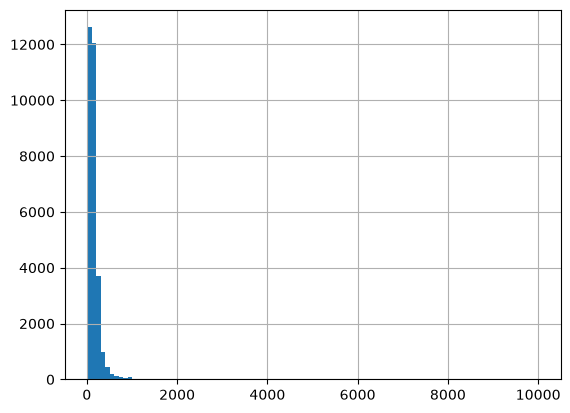

In [ ]:
#Changing to Numeric
df[var] = pd.to_numeric(df[var].str.replace(',',''), errors = 'coerce')
df['price_nan'] = df[var].isnull()


print("Printing the df[var] with unique():\n", df[var].unique(), '\n')
print("Printing the df[var] with value_counts():\n", df[var].value_counts(), '\n')

print("After coercion: \n", df[var].describe(), '\n')
df[var].hist(bins = 100)

In [ ]:
#Missing Data
missing_price_data = df[df[var].isnull()]
print(missing_price_data, type(missing_price_data)) #There were 181 NaN values in the Price attribute

#Reprint DataFrame
df[var]

Empty DataFrame
Columns: [Host Id, Host Since, Name, Neighbourhood , Property Type, Review Scores Rating (bin), Room Type, Zipcode, Beds, Number of Records, Number Of Reviews, Price, Review Scores Rating, price_nan]
Index: [] <class 'pandas.DataFrame'>


0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: int64

In [ ]:
#Question 1 Part 2

police = pd.read_csv("C:/Users/charl/Downloads/mn_police_use_of_force.csv")

print(police.shape, '\n')
print(police.head(),'\n')
print(police["subject_injury"], '\n')

print(police["subject_injury"].unique(), '\n')
subject_type_uniq_val = police["subject_injury"].unique()

print(subject_type_uniq_val[1], len(subject_type_uniq_val[1]), '\n')
print(subject_type_uniq_val[2], len(subject_type_uniq_val[2]), '\n')

print(police['subject_injury'].isna().sum())
print(police['subject_injury'].notna().sum())

(12925, 13) 

     response_datetime               problem is_911_call primary_offense  \
0  2016/01/01 00:47:36  Assault in Progress          Yes          DASLT1   
1  2016/01/01 02:19:34                Fight           No          DISCON   
2  2016/01/01 02:19:34                Fight           No          DISCON   
3  2016/01/01 02:28:48                Fight           No          PRIORI   
4  2016/01/01 02:28:48                Fight           No          PRIORI   

  subject_injury         force_type   force_type_action   race     sex   age  \
0            NaN       Bodily Force  Body Weight to Pin  Black    Male  20.0   
1            NaN  Chemical Irritant       Personal Mace  Black  Female  27.0   
2            NaN  Chemical Irritant       Personal Mace  White  Female  23.0   
3            NaN  Chemical Irritant  Crowd Control Mace  Black    Male  20.0   
4            NaN  Chemical Irritant  Crowd Control Mace  Black    Male  20.0   

         type_resistance  precinct   neighborhoo

In [ ]:
pd.crosstab(police["subject_injury"], police["force_type"])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal Projectile,Police K9 Bite,Taser
subject_injury,,,,,,,,,
No,0,1093,131,2,33,34,1,2,150
Yes,2,1286,41,0,44,40,2,44,172


           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

<Axes: >

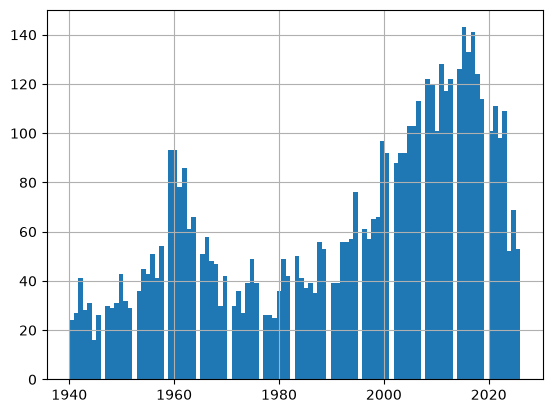

In [ ]:
#Question 2

shark_df = pd.read_excel("C:/Users/charl/Downloads/GSAF5.xls")

print(shark_df.head(), '\n')

print(shark_df.columns, '\n')

shark_df = shark_df.drop(["pdf","href formula","href",'Case Number','Case Number.1','original order','Unnamed: 21', "Unnamed: 22"], axis =1)

print(shark_df["Year"].unique())

shark_df['Year'] = pd.to_numeric(shark_df['Year'], errors='coerce')
shark_df = shark_df[(shark_df['Year'] >= 1500) & (shark_df['Year'] <= 2026)]

print(shark_df["Year"].unique(), '\n')

shark_df = shark_df.query("Year >= 1940")

print(shark_df["Year"],'\n')

shark_df['Year'].hist(bins = 100)

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

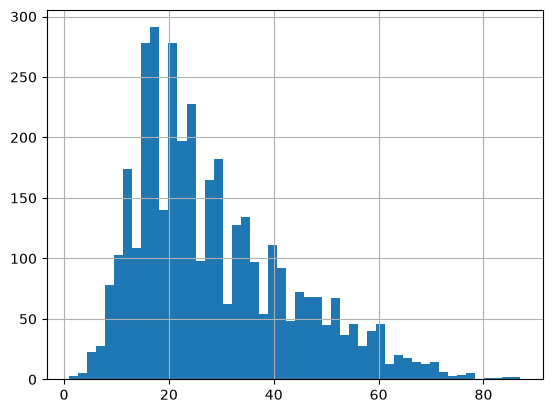

In [ ]:
#Cleaning Age Variable

import re

print(shark_df["Age"].unique(), '\n')

cleaned_ages = []
for age in shark_df["Age"]:
    if pd.isna(age):
        cleaned_ages.append(None)
        continue

    age_str = str(age)

    #extract numbers
    nums = re.findall(r'\d+(?:\.\d+)?', age_str)

    if len(nums) == 0:
        cleaned_ages.append(None)
    elif len(nums) == 1:
        cleaned_ages.append(float(nums[0]))
    else:
        # average multiple numbers
        total = 0
        for n in nums:
            total += float(n)
        cleaned_ages.append(total / len(nums))

shark_df["Age"] = cleaned_ages

print(shark_df["Age"].unique())

shark_df["Age"].hist(bins=50)

<StringArray>
['F', 'M', 'M ', 'M F', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2']
Length: 11, dtype: str
<StringArray>
['F', 'M', nan]
Length: 3, dtype: str


<Axes: >

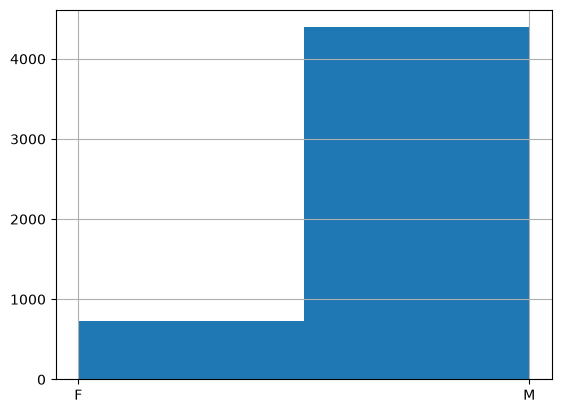

In [ ]:
#Victims Male

print(shark_df["Sex"].unique())

shark_df["Sex"] = shark_df["Sex"].str.upper().str.replace(" ","")

valid_sex = ["M", "F"]
shark_df.loc[~shark_df["Sex"].isin(valid_sex), "Sex"] = None

print(shark_df["Sex"].unique())

shark_df["Sex"].hist(bins = 2)

<Axes: >

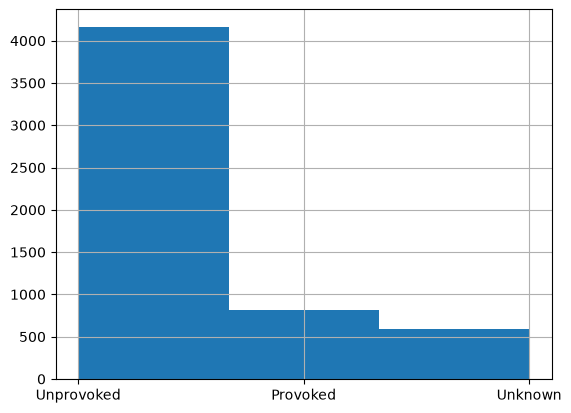

In [ ]:
#Clean Type Variable

type_map = {
    "Invalid": "Unknown",
    "Unverified": "Unknown",
    "Questionable": "Unknown",
    "Unconfirmed": "Unknown",
    "Under Investigation": "Unknown",
    "Boat": "Provoked",
    "Watercraft": "Provoked",
    "Sea Disaster": "Unknown",
    "?":np.nan,

}

shark_df["Type"] = shark_df["Type"].str.title()
shark_df["Type"] = shark_df["Type"].str.strip(" ")
shark_df["Type"] = shark_df["Type"].replace(type_map)

shark_df["Type"].hist(bins=3)

### *Reflection on AI assistance
In your own words without generative AI.

After submitting my code in Microsoft Copilot, I was able to tighten up many aspects of what I originally wrote. It allowed me to simplify my cleaning of many varibables like that of the subject_injury variable in the police dataset. The greatest improvement was in my cleaning of the Age variable in the shark dataset. My original code was very lengthy and clunky, largely due to me figuring out how to manipulate number arrays and pandas Series, something I had never done before. The generative AI turned what I thought was a difficult task into a much smoother procedure. Additionally, it allowed me to fix some mistakes I made when I was cleaning the shark dataset and it's Year and Type variables.

While it may look like I implemented many of its suggestions, I did follow up on its initial response because the recommended code automatically suggested I drop the NaN values. I did not want to do that because they are still data points. So I changed some code like the method isnull() and notnull() to isna() and notna() to keep the NaN values. Additionally, the AI suggested code for cleaning the Sex variable did not get rid of all of the dirty pieces of the variable so I kept some of my stripping and replacing code to completely clean it.

To make sure everything worked, I ran the new edited code through VS Studio and then compared it's output to the output of my previous code. I also kept my usage of the .unique() methods throughout because it helps me visualize how the output changes as I clean it step by step. As I practice more with data wrangling, I do plan to incorporate its suggestion to use more functions rather than inline code.